In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("rocket_fuel_data.csv")

In [48]:
df["Temperature_C"] = df["Temperature_C"].fillna(df["Temperature_C"].mean())
df["Efficiency_Percent"] = df["Efficiency_Percent"].fillna(df["Efficiency_Percent"].mean())
df["Oxygen_Level_Percent"] = df["Oxygen_Level_Percent"].fillna(df["Oxygen_Level_Percent"].mean())
df["Pressure_atm"] = df["Pressure_atm"].fillna(df["Pressure_atm"].median())


In [49]:
df = df.sort_values(
    ["Temperature_C", "Efficiency_Percent"],
    ascending=[True, False]
)

In [50]:
df["Power_Index"] = df["Thrust_kN"] * df["Efficiency_Percent"]
df = df.reset_index(drop=True)

df.to_csv("modified.csv")

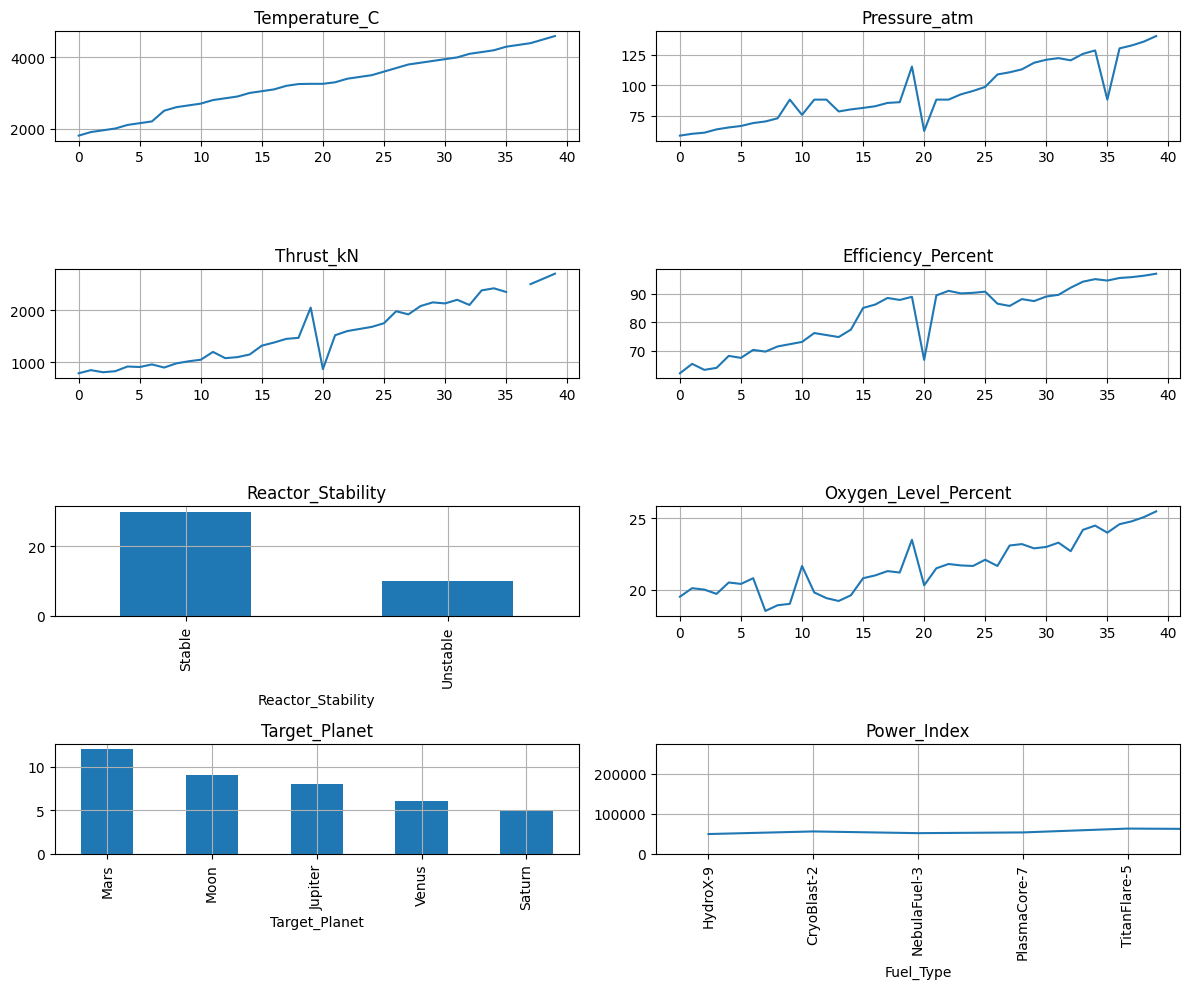

In [51]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10))

# Flatten axes for easier indexing
axes = axes.flatten()

for i, col in enumerate(df.columns):
    if col == "Fuel_Type" or col == "Reactor_Stability" or col == "Target_Planet":
        df[col].value_counts().plot(kind="bar", ax=axes[i-1])
    else:
        axes[i-1].plot(df.index, df[col])

    axes[i-1].set_title(col)
    axes[i-1].grid(True)

plt.tight_layout()
plt.show()